# 1. Extragerea Datelor (Data Ingestion)
Ne conectăm la API-ul openFDA FAERS pentru a extrage un eșantion de rapoarte recente cu reacții adverse. Datele vor fi descărcate în format JSON și salvate local în folderul `data/` pentru reproductibilitate.

In [2]:
import requests
import json
import os
import time
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv('FDA_API_KEY')
os.makedirs('../data', exist_ok=True)

def fetch_fda_data(total_records=5000, start_date='20240101', end_date='20240131'):
    base_url = "https://api.fda.gov/drug/event.json"
    all_results = []
    headers = {'User-Agent': 'PV-Copilot/1.0'}
    key_param = f"api_key={API_KEY}&" if API_KEY else ""

    for skip in range(0, total_records, 1000):
        query = f'?{key_param}search=receivedate:[{start_date}+TO+{end_date}]&limit=1000&skip={skip}'
        print(f"  Descarcam {skip}–{skip+1000}...")
        response = requests.get(base_url + query, headers=headers)
        if response.status_code == 200:
            data = response.json().get('results', [])
            all_results.extend(data)
            if len(data) < 1000:
                break  # nu mai sunt date
        elif response.status_code == 404:
            print("  Nu mai exista date pentru acest interval.")
            break
        else:
            print(f"  Eroare: {response.status_code}")
            break
        time.sleep(1)

    return all_results

# ============================================================
# DESCARCA PE ANI SEPARATI SI COMBINA
# ============================================================
ani = {
    '2022': ('20220101', '20221231'),
    '2023': ('20230101', '20231231'),
    '2024': ('20240101', '20241231'),
}

all_raw = []
for an, (start, end) in ani.items():
    print(f"\n📅 Descarcam {an}...")
    data_an = fetch_fda_data(total_records=3000, start_date=start, end_date=end)
    all_raw.extend(data_an)
    print(f"   => {len(data_an)} rapoarte pentru {an}")
    time.sleep(2)  # pauza intre ani

print(f"\n✅ Total brut: {len(all_raw)} rapoarte (2022-2024)")

with open('../data/faers_raw_sample.json', 'w') as f:
    json.dump(all_raw, f)

raw_reports = all_raw


📅 Descarcam 2022...
  Descarcam 0–1000...
  Descarcam 1000–2000...
  Descarcam 2000–3000...
   => 3000 rapoarte pentru 2022

📅 Descarcam 2023...
  Descarcam 0–1000...
  Descarcam 1000–2000...
  Descarcam 2000–3000...
   => 3000 rapoarte pentru 2023

📅 Descarcam 2024...
  Descarcam 0–1000...
  Descarcam 1000–2000...
  Descarcam 2000–3000...
   => 3000 rapoarte pentru 2024

✅ Total brut: 9000 rapoarte (2022-2024)


# 2. Procesarea și Aplatizarea Datelor (Data Flattening)
Rapoartele FAERS vin într-un format JSON imbricat. Pentru a putea aplica funcții statistice și a antrena/informa modelul AI, trebuie să "aplatizăm" aceste date într-un `DataFrame` Pandas. 
Vom crea câte un rând separat pentru fiecare combinație unică de **Medicament - Reacție Adversă** dintr-un raport.

In [12]:
import pandas as pd

def flatten_reports(reports):
    flattened = []
    
    for report in reports:
        # Extragem ID-ul și data raportului
        report_id = report.get('safetyreportid', 'Necunoscut')
        date = report.get('receivedate', 'Necunoscut')
        
        patient = report.get('patient', {})
        
        # Extragem sexul (1 = M, 2 = F)
        sex_code = patient.get('patientsex', '0')
        sex = 'M' if sex_code == '1' else ('F' if sex_code == '2' else 'Unknown')
        
        # Extragem toate reacțiile adverse raportate de acest pacient
        reactions = [r.get('reactionmeddrapt', '').upper() for r in patient.get('reaction', [])]
        
        # Iterăm prin medicamentele luate de pacient
        drugs = patient.get('drug', [])
        for drug in drugs:
            drug_name = drug.get('medicinalproduct', '').upper()
            
            # 1 = Medicament Suspectat, 2 = Concomitent, 3 = Interacțiune
            char_code = drug.get('drugcharacterization', '0')
            role = 'Suspect' if char_code == '1' else 'Concomitent/Interacțiune'
            
            # Generăm perechile Medicament - Reacție
            for reaction in reactions:
                flattened.append({
                    'Report_ID': report_id,
                    'Date': date,
                    'Sex': sex,
                    'Drug_Name': drug_name,
                    'Role': role,
                    'Reaction': reaction
                })
                
    return pd.DataFrame(flattened)

# Apelăm funcția folosind datele brute din variabila raw_reports
df = flatten_reports(raw_reports)

# Curățăm datele: ștergem rândurile unde nu avem un nume de medicament sau o reacție validă
df.dropna(subset=['Drug_Name', 'Reaction'], inplace=True)
df = df[(df['Drug_Name'] != '') & (df['Reaction'] != '')]

# ── NORMALIZARE Reaction — whitespace + majuscule ────────
# Reactiile vin deja ca MedDRA Preferred Term din FAERS,
# dar pot avea spatii multiple sau minuscule. Le curatam consistent.
df['Reaction'] = df['Reaction'].str.strip().str.upper()
df['Reaction'] = df['Reaction'].str.replace(r'\s+', ' ', regex=True)

# ── NORMALIZARE Reaction — whitespace + majuscule ────────
# Reactiile vin deja ca MedDRA Preferred Term din FAERS,
# dar pot avea spatii multiple sau minuscule. Le curatam consistent.
df['Reaction'] = df['Reaction'].str.strip().str.upper()
df['Reaction'] = df['Reaction'].str.replace(r'\s+', ' ', regex=True)

# ── NORMALIZARE Drug_Name via RxNorm ─────────────────────
# Normalizam DOAR top 200 medicamente frecvente.
# Medicamentele rare (sub top 200) nu vor genera semnal PRR valid
# oricum (criteriul Evans: a >= 3), deci nu merita procesate.
# Top 200 x 0.05s = ~10 secunde in loc de 9 minute.

def normalizeaza_rxnorm(denumire):
    """Apeleaza RxNorm API si returneaza INN-ul (ingredient activ) sau originalul ca fallback.
    
    3 pasi:
    1. Cauta RxCUI dupa denumire (comerciala sau INN)
    2. Din RxCUI, extrage ingredientul activ (tty=IN) = INN-ul real
    3. Fallback la numele original daca orice pas esueaza
    """
    try:
        # Pasul 1: denumire → RxCUI
        url = f'https://rxnav.nlm.nih.gov/REST/rxcui.json?name={denumire}&search=2'
        r = requests.get(url, timeout=8)
        ids = r.json().get('idGroup', {}).get('rxnormId', [])
        if not ids:
            return denumire  # negasit in RxNorm
        rxcui = ids[0]

        # Pasul 2: RxCUI → ingredient activ (INN)
        # tty=IN = Ingredient — tipul de concept RxNorm pentru substanta activa
        url2 = f'https://rxnav.nlm.nih.gov/REST/rxcui/{rxcui}/related.json?tty=IN'
        r2 = requests.get(url2, timeout=8)
        concepte = (r2.json()
                      .get('relatedGroup', {})
                      .get('conceptGroup', []))
        for grup in concepte:
            if grup.get('tty') == 'IN':
                props = grup.get('conceptProperties', [])
                if props:
                    return props[0]['name'].upper()  # INN-ul real

        return denumire  # RxCUI gasit dar fara ingredient activ → fallback
    except:
        return denumire  # orice eroare (timeout, HTTP 500) → fallback la original

TOP_N = 100
top_medicamente = df['Drug_Name'].value_counts().head(TOP_N).index.tolist()
total_unice = df['Drug_Name'].nunique()

print(f'Normalizam top {TOP_N} medicamente frecvente (din {total_unice} unice total)...')
print(f'Medicamentele rare (restul de {total_unice - TOP_N}) raman cu numele original.')

mapping = {}
for i, denumire in enumerate(top_medicamente):
    mapping[denumire] = normalizeaza_rxnorm(denumire)
    if i % 20 == 0:
        print(f'  {i}/{TOP_N} procesate...')
    time.sleep(0.05)  # 0.05s pauza — evita rate limit RxNorm (~20 req/sec)

# Medicamentele din top 200 → INN normalizat
# Medicamentele rare → raman cu numele original (fillna)
df['Drug_Name'] = df['Drug_Name'].map(mapping).fillna(df['Drug_Name'])
print('Normalizare finalizata.')

# Salvăm dataset-ul procesat în format CSV
df.to_csv('../data/cleaned_faers_data.csv', index=False)

print(f"Dimensiunea tabelului final: {df.shape[0]} asocieri medicament-reacție și {df.shape[1]} atribute.")
display(df.head())

Normalizam top 100 medicamente frecvente (din 2812 unice total)...
Medicamentele rare (restul de 2712) raman cu numele original.
  0/100 procesate...
  20/100 procesate...
  40/100 procesate...
  60/100 procesate...
  80/100 procesate...
Normalizare finalizata.
Dimensiunea tabelului final: 162798 asocieri medicament-reacție și 6 atribute.


,Report_ID,Date,Sex,Drug_Name,Role,Reaction
0,20268558,20220101,F,OXYCODONE,Suspect,DRUG DEPENDENCE
1,20268558,20220101,F,OXYCODONE,Suspect,PAIN
2,20268558,20220101,F,OXYCODONE,Suspect,EMOTIONAL DISTRESS
3,20268558,20220101,F,HYDROCODONE BITARTRATE AND ACETAMINOPHEN,Suspect,DRUG DEPENDENCE
4,20268558,20220101,F,HYDROCODONE BITARTRATE AND ACETAMINOPHEN,Suspect,PAIN


In [10]:
comparatie = pd.DataFrame({
    'Denumire_comerciala': top_medicamente,
    'INN_normalizat': [mapping[d] for d in top_medicamente]
})

modificate = comparatie[comparatie['Denumire_comerciala'] != comparatie['INN_normalizat']]
print(f'Medicamente cu denumire schimbata: {len(modificate)} din {len(top_medicamente)}')
display(modificate)

KeyError: 'MOUNJARO'

In [11]:
mounjaro = df[df['Drug_Name'] == 'MOUNJARO']
print(f'Total rapoarte Mounjaro: {len(mounjaro)}')
display(mounjaro['Reaction'].value_counts().head(20))

Total rapoarte Mounjaro: 544


Reaction
INCORRECT DOSE ADMINISTERED                         69
OFF LABEL USE                                       64
INJECTION SITE PAIN                                 64
INJECTION SITE URTICARIA                            42
GASTROINTESTINAL DISORDER                           29
INJECTION SITE HAEMORRHAGE                          25
DIARRHOEA                                           23
INJECTION SITE IRRITATION                           22
NAUSEA                                              18
PRODUCT DOSE OMISSION ISSUE                         17
WEIGHT INCREASED                                    12
DYSPEPSIA                                           10
EXTRA DOSE ADMINISTERED                              9
VOMITING                                             9
INJECTION SITE BRUISING                              8
INAPPROPRIATE SCHEDULE OF PRODUCT ADMINISTRATION     8
HEADACHE                                             7
INJECTION SITE ERYTHEMA                              6
F

# 3. Analiza Exploratorie a Datelor (EDA)
În această secțiune validăm calitatea datelor și extragem primele insight-uri. Ne vom concentra pe:
1. Identificarea celor mai frecvente reacții adverse.
2. Identificarea medicamentelor raportate cel mai des ca fiind "Suspecte" pentru aceste reacții.
Acest pas ne va evidenția și "zgomotul" din date (denumiri comerciale amestecate cu denumiri generice), problemă pe care o vom rezolva în etapa următoare prin integrarea unui tool de Normalizare (RxNorm) pentru agentul AI.

NameError: name 'df' is not defined

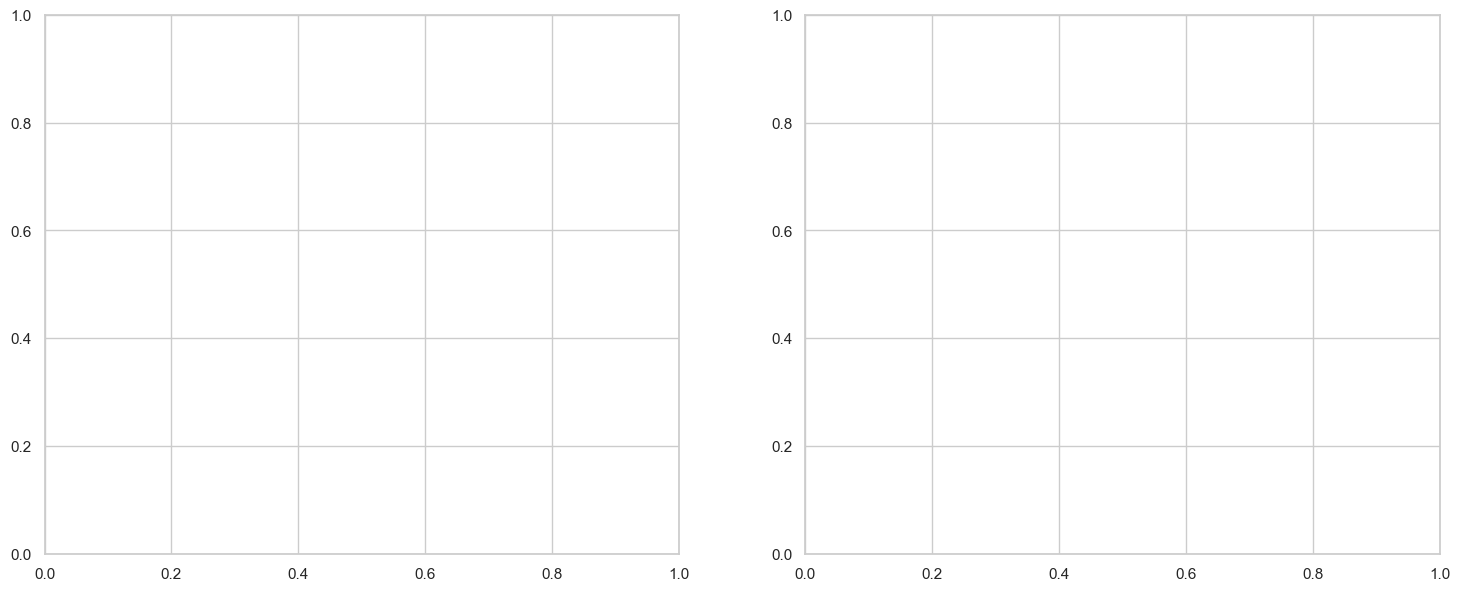

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setăm stilul graficelor
sns.set_theme(style="whitegrid")

# Creăm o figură cu două grafice (stânga - reacții, dreapta - medicamente)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Grafic 1: Top 10 Reacții Adverse
top_reactions = df['Reaction'].value_counts().head(10)
sns.barplot(x=top_reactions.values, y=top_reactions.index, hue=top_reactions.index, legend=False, ax=axes[0], palette="flare")
axes[0].set_title('Top 10 Reacții Adverse Raportate', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Număr de apariții')
axes[0].set_ylabel('Tipul Reacției (MedDRA)')

# Grafic 2: Top 10 Medicamente Suspecte
df_suspect = df[df['Role'] == 'Suspect']
top_drugs = df_suspect['Drug_Name'].value_counts().head(10)
sns.barplot(x=top_drugs.values, y=top_drugs.index, hue=top_drugs.index, legend=False, ax=axes[1], palette="crest")
axes[1].set_title('Top 10 Medicamente Marcate ca "Suspecte"', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Număr de asocieri în rapoarte')
axes[1].set_ylabel('Denumire Medicament (Nenormalizat)')

plt.tight_layout()
plt.show()

# Scurt raport text pentru datele lipsă
print("=== Raport de Calitate a Datelor ===")
print("Valori lipsă pe fiecare coloană:")
print(df.isnull().sum())
print("\nConcluzie preliminară: Datele sunt consistente, dar se observă duplicarea implicită a denumirilor (brand vs. substanță activă).")

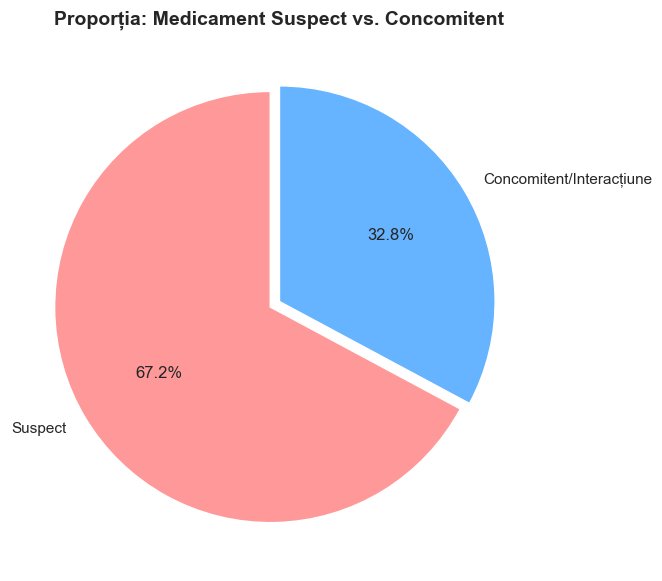

Din 162798 de înregistrări brute, am identificat 62807 asocieri unice Medicament-Reacție.


In [10]:
# Proporția rolurilor medicamentelor în rapoarte
plt.figure(figsize=(7, 7))
role_counts = df['Role'].value_counts()
plt.pie(role_counts, labels=role_counts.index, autopct='%1.1f%%', 
        colors=['#ff9999','#66b3ff'], startangle=90, explode=(0.05, 0))
plt.title('Proporția: Medicament Suspect vs. Concomitent', fontsize=14, fontweight='bold')
plt.show()

# Calculăm asocierile unice
unique_signals = df.groupby(['Drug_Name', 'Reaction']).size().reset_index(name='Count')
print(f"Din {df.shape[0]} de înregistrări brute, am identificat {unique_signals.shape[0]} asocieri unice Medicament-Reacție.")

### 📌 Concluziile Analizei Exploratorii (EDA)
1. **Zgomotul Nomenclatorului:** Observăm în grafice că medicamentele apar sub diverse denumiri comerciale (brand-uri). Asta înseamnă că asocierile unice calculate mai sus sunt fragmentate. **Această problemă validează necesitatea agentului nostru AI de a utiliza tool-ul `RxNorm` pentru normalizare în etapa următoare.**
2. **Volumul de Date:** Prezența unui număr atât de mare de asocieri unice (multe dintre ele fiind medicamente concomitente, nu neapărat cauza principală) demonstrează de ce experții umani sunt supraîncărcați. Avem nevoie de **calculul metricilor PRR/ROR (Săptămâna 14)** pentru a filtra și prioritiza matematic doar semnalele cu adevărat periculoase.

In [7]:
# Vedem ce s-a schimbat dupa normalizare
top200_inainte = df_original['Drug_Name'].value_counts().head(200).index.tolist()
# (sau daca nu ai salvat df_original, reincarca CSV-ul vechi)

comparatie = pd.DataFrame({
    'Denumire_comerciala': top_medicamente,
    'INN_normalizat': [mapping.get(d, d) for d in top_medicamente]
})

# Filtram doar cele unde s-a schimbat ceva
modificate = comparatie[comparatie['Denumire_comerciala'] != comparatie['INN_normalizat']]
print(f'Medicamente cu denumire schimbata: {len(modificate)} din {len(top_medicamente)}')
display(modificate)

NameError: name 'df_original' is not defined